# Proyecto 1 - Monitoreo Transaccional
### Detectar lo que el orden revela

**Universidad del Valle - Deep Learning 2026**

Este notebook cubre la parte de **Persona 1** del equipo:

1. Generación de datos sintéticos e integridad de datos.
2. Partición temporal train / validación / test.
3. Preparación de variables para el Modelo A.
4. **Modelo A:** línea base sin orden.
5. Análisis económico preliminar realizado únicamente en validación.

Las secciones de **Modelo B**, **Apuesta C**, las **pruebas de falsificación** y la
**evaluación final única sobre test** serán agregadas posteriormente en este mismo
notebook, usando exactamente el mismo dataset, partición y horizonte de predicción.

> **Protocolo de test sellado:** `seed=42` se considera una ejecución piloto y se
> descarta para la evaluación final. Esta versión utiliza `seed=2027`. Durante el
> desarrollo solamente se observan train y validación. No se calculan predicciones,
> métricas, gráficas, umbrales ni costos sobre test. Test se evaluará una sola vez,
> después de congelar A, B, C y todas las decisiones experimentales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, precision_score,
                              recall_score, f1_score, confusion_matrix)
from sklearn.ensemble import HistGradientBoostingClassifier

import generador  # módulo reproducible incluido como generador.py

pd.set_option("display.max_columns", 20)
np.random.seed(2027)

## 1. Generación de datos sintéticos e integridad de datos

**Por qué usamos datos sintéticos:** elegimos la Ruta A porque permite controlar qué
patrones dependen del orden y documentar esa dependencia con precisión, algo difícil de
garantizar con un conjunto real sin etiquetas del mecanismo de fraude.

**Cómo se generan los datos:**

- `N` clientes con perfiles heterogéneos: frecuencia diaria de transacciones (Gamma),
  monto típico (lognormal por cliente), comercios preferidos y canal preferido.
- Transacciones legítimas simuladas como un proceso de llegadas por día (Poisson).
- Tres mecanismos de fraude inyectados en un subconjunto de clientes.
- Una semilla fija (`seed=2027`) hace que el dataset sea reproducible.

### Los tres tipos de fraude

| Tipo | Patrón | ¿Depende del orden? |
|---|---|---|
| `escalada` | 3-5 compras pequeñas seguidas de una compra grande, dentro de una ventana corta. | **Sí, principalmente.** Al barajar la secuencia desaparece el patrón pequeño-pequeño-grande, aunque se conservan los eventos. |
| `rafaga` | 8-12 transacciones en 30-45 minutos, con montos moderados y comercios variados. | No principalmente. La señal está en el conteo dentro de la ventana y puede ser capturada por agregados. |
| `comercio_atipico` | Una transacción grande, en horario inusual y en un comercio nunca usado previamente por ese cliente. | No depende del orden. Esperamos que A tenga dificultad porque no recibe una variable que indique si el comercio es nuevo para ese cliente. |

### Caso de fallo esperado, declarado antes del entrenamiento

Antes de entrenar, esperamos que el Modelo A tenga su peor desempeño en
`comercio_atipico`. `FEATURES_A` solamente incluye frecuencia **global** del comercio y
diversidad de comercios durante siete días; ninguna variable indica causalmente si ese
cliente específico había usado antes ese comercio. El horario tampoco debería bastar,
porque las transacciones legítimas pueden ocurrir a cualquier hora.

Esta expectativa se confirma o refuta usando **validación**, nunca test.

### Variables agregadas causales

Para cada transacción, el generador calcula usando exclusivamente el historial anterior
del mismo cliente:

- `monto_prom_24h`
- `n_trans_ultima_hora`
- `monto_max_dia`
- `diversidad_comercios_7d`

El código completo y comentado está en `generador.py`.

In [2]:
cfg = generador.Config(
    n_clientes=3000,
    periodo_dias=180,
    tasa_fraude_clientes=0.08,
    seed=2027,
)
df = generador.generar_dataset(cfg)

# Durante el desarrollo no se inspeccionan las etiquetas de test.
df_desarrollo = df.loc[df.dia < 150]

print("Tamaño total del dataset:", df.shape)
print("Clientes:", df["client_id"].nunique())
print("Tasa de fraude en train + validación:", round(df_desarrollo["label"].mean(), 5))
print()
print("Mecanismos en train + validación:")
print(df_desarrollo["fraud_type"].value_counts())
df.head()

Tamaño total del dataset: (407524, 16)
Clientes: 3000
Tasa de fraude en train + validación: 0.00318

Mecanismos en train + validación:
fraud_type
legitimo            338304
rafaga                 583
escalada               439
comercio_atipico        58
Name: count, dtype: int64


,transaction_id,client_id,seq_index,dia,timestamp,amount,merchant,merchant_name,channel,channel_name,monto_prom_24h,n_trans_ultima_hora,monto_max_dia,diversidad_comercios_7d,fraud_type,label
0,0,0,0,0,11.885029,39.580858,6,streaming,1,online,0.000000,0.0,0.000000,0.0,legitimo,0
1,1,0,1,2,49.127790,56.358697,17,electrodomesticos,1,online,0.000000,0.0,0.000000,1.0,legitimo,0
2,2,0,2,4,105.737331,27.352933,14,mascotas,1,online,0.000000,0.0,0.000000,2.0,legitimo,0
3,3,0,3,4,107.972145,80.939783,14,mascotas,1,online,27.352933,0.0,27.352933,3.0,legitimo,0
4,4,0,4,6,158.316809,79.397844,14,mascotas,1,online,0.000000,0.0,0.000000,3.0,legitimo,0


**Reproducibilidad:** volver a ejecutar
el generador con la misma configuración y `seed=2027` produce exactamente el mismo
dataset. La semilla forma parte de la configuración que debe conservarse junto con los
artefactos.

## 2. Partición temporal

Usamos el día de simulación como eje temporal; no se realiza una partición aleatoria.

- **Train:** días 0-119.
- **Validación:** días 120-149.
- **Test sellado:** días 150-179.

Controles contra fuga de información:

- Las variables agregadas son causales y nunca observan transacciones futuras.
- Las frecuencias y cualquier transformación aprendida se ajustan solamente con train.
- Validación se usa para arquitectura, hiperparámetros, hipótesis y umbral.
- Durante el desarrollo no se inspeccionan etiquetas ni resultados de test.

In [3]:
df["dia_semana"] = df["dia"] % 7
df["hora_del_dia"] = df["timestamp"] % 24
df["split"] = np.where(
    df.dia < 120,
    "train",
    np.where(df.dia < 150, "val", "test"),
)

# Se muestran únicamente tamaños y rangos temporales, sin estadísticas de las
# etiquetas de test.
resumen_temporal = df.groupby("split").agg(
    n_transacciones=("transaction_id", "size"),
    primer_dia=("dia", "min"),
    ultimo_dia=("dia", "max"),
)

resumen_desarrollo = (
    df.loc[df.split.isin(["train", "val"])]
      .groupby("split")
      .agg(
          n_transacciones=("label", "size"),
          tasa_fraude=("label", "mean"),
          n_fraudes=("label", "sum"),
      )
)

print("Partición temporal (test sin inspeccionar):")
display(resumen_temporal)
print("Etiquetas observadas solamente en desarrollo:")
display(resumen_desarrollo)

Partición temporal (test sin inspeccionar):


,n_transacciones,primer_dia,ultimo_dia
split,,,
test,68140,150,179
train,271752,0,119
val,67632,120,149


Etiquetas observadas solamente en desarrollo:


,n_transacciones,tasa_fraude,n_fraudes
split,,,
train,271752,0.002999,815
val,67632,0.003918,265


## 3. Preparación de variables para el Modelo A

El Modelo A no lee una secuencia. Recibe variables agregadas y atributos de la
transacción actual. Las frecuencias de comercio y canal se ajustan exclusivamente con
train y se aplican sin cambios a validación y test.

In [4]:
train_mask = df.split == "train"
freq_comercio = df.loc[train_mask].groupby("merchant").size() / train_mask.sum()
freq_canal = df.loc[train_mask].groupby("channel").size() / train_mask.sum()

df["merchant_freq"] = df["merchant"].map(freq_comercio).fillna(0.0)
df["channel_freq"] = df["channel"].map(freq_canal).fillna(0.0)

FEATURES_A = [
    "amount",
    "monto_prom_24h",
    "n_trans_ultima_hora",
    "monto_max_dia",
    "diversidad_comercios_7d",
    "merchant_freq",
    "channel_freq",
    "hora_del_dia",
    "dia_semana",
]

Xtr = df.loc[df.split == "train", FEATURES_A]
ytr = df.loc[df.split == "train", "label"]
Xval = df.loc[df.split == "val", FEATURES_A]
yval = df.loc[df.split == "val", "label"]

# Xte puede prepararse sin examinar sus etiquetas; yte se creará únicamente en la
# evaluación final, cuando A, B y C estén congelados.
Xte = df.loc[df.split == "test", FEATURES_A]

print("Variables del Modelo A:", FEATURES_A)
print("Train:", Xtr.shape, " Validación:", Xval.shape, " Test sellado:", Xte.shape)

Variables del Modelo A: ['amount', 'monto_prom_24h', 'n_trans_ultima_hora', 'monto_max_dia', 'diversidad_comercios_7d', 'merchant_freq', 'channel_freq', 'hora_del_dia', 'dia_semana']
Train: (271752, 9)  Validación: (67632, 9)  Test sellado: (68140, 9)


## 4. Modelo A - Línea base sin orden

Usamos gradient boosting de árboles (`HistGradientBoostingClassifier`) sobre variables
agregadas. `class_weight="balanced"` compensa el desbalance y **AUC-PR** es la métrica
principal. No usamos exactitud como métrica principal porque un clasificador que nunca
detectara fraude tendría cerca de 99.7 % de exactitud y sería inútil.

Esta implementación pertenece a scikit-learn y evita depender de instalaciones externas
durante la reproducción del notebook.

In [5]:
modelo_a = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=4,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=cfg.seed,
)
modelo_a.fit(Xtr, ytr)

puntaje_val = modelo_a.predict_proba(Xval)[:, 1]
print("AUC-PR (validación):", round(average_precision_score(yval, puntaje_val), 4))

AUC-PR (validación): 0.7368


### Desempeño por mecanismo, calculado en validación

Este diagnóstico permite formular las hipótesis de B y C sin consultar test. Todos los
mecanismos se comparan contra el mismo conjunto de transacciones legítimas de
validación.

In [6]:
df_val = df.loc[df.split == "val"].copy()
df_val["puntaje_a"] = puntaje_val

filas = []
for tipo in ["escalada", "rafaga", "comercio_atipico"]:
    mask = (df_val.fraud_type == tipo) | (df_val.label == 0)
    sub = df_val.loc[mask]
    if sub.label.sum() > 0:
        filas.append({
            "fraud_type": tipo,
            "n_positivos_val": int(sub.label.sum()),
            "AUC-PR_Modelo_A_val": average_precision_score(
                sub.label, sub.puntaje_a
            ),
        })

resumen_tipo_val = pd.DataFrame(filas)
resumen_tipo_val

,fraud_type,n_positivos_val,AUC-PR_Modelo_A_val
0,escalada,130,0.669813
1,rafaga,126,0.746658
2,comercio_atipico,9,0.014679


**Lectura basada únicamente en
validación:** A debería ser más fuerte en `rafaga`, porque recibe el conteo de la última
hora; debería ser más débil en `escalada`, que fue diseñada para depender del orden; y
esperamos su peor desempeño en `comercio_atipico`, porque no recibe una señal de novedad
específica por cliente.

Para B, la hipótesis que debe intentar refutarse es que su posible mejora en
`escalada` desaparecerá o se reducirá al barajar el orden dentro de las secuencias.

## 5. Análisis económico preliminar en validación

Costos definidos por el comité:

- Fraude no detectado: **Q4,200**.
- Transacción legítima bloqueada: **Q180**.

El umbral se selecciona únicamente con validación. Esta función debe reutilizarse para
A, B y C. La comparación económica sobre test se realizará una sola vez al final.

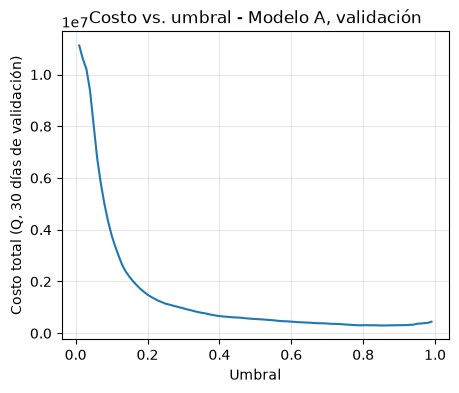

Umbral elegido en validación: 0.85
Costo en validación: Q 299,100
Precisión: 0.486
Recall: 0.766
F1: 0.594


In [7]:
COSTO_FRAUDE_NO_DETECTADO = 4200
COSTO_BLOQUEO_LEGITIMO = 180


def costo_total(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    costo = (
        fn * COSTO_FRAUDE_NO_DETECTADO
        + fp * COSTO_BLOQUEO_LEGITIMO
    )
    return costo, fp, fn, tp, tn


umbrales = np.linspace(0.01, 0.99, 99)
resultados = []
for umbral in umbrales:
    pred_val = (puntaje_val >= umbral).astype(int)
    costo, fp, fn, tp, tn = costo_total(yval, pred_val)
    resultados.append((umbral, costo, fp, fn, tp, tn))

res_df = pd.DataFrame(
    resultados,
    columns=["umbral", "costo_total_val", "fp", "fn", "tp", "tn"],
)

plt.figure(figsize=(5, 4))
plt.plot(res_df.umbral, res_df.costo_total_val)
plt.xlabel("Umbral")
plt.ylabel("Costo total (Q, 30 días de validación)")
plt.title("Costo vs. umbral - Modelo A, validación")
plt.grid(alpha=0.3)
plt.show()

mejor = res_df.loc[res_df.costo_total_val.idxmin()]
umbral_a = float(mejor.umbral)
pred_val_final = (puntaje_val >= umbral_a).astype(int)

print("Umbral elegido en validación:", round(umbral_a, 2))
print("Costo en validación: Q {:,.0f}".format(mejor.costo_total_val))
print("Precisión:", round(precision_score(yval, pred_val_final), 3))
print("Recall:", round(recall_score(yval, pred_val_final), 3))
print("F1:", round(f1_score(yval, pred_val_final), 3))

## 6. Decisiones que deben fijarse antes de construir B

Antes de programar el modelo secuencial, el equipo debe registrar por escrito:

- Qué predice cada secuencia y cuál es el horizonte de predicción.
- Longitud máxima `k` y método de padding.
- Variables recibidas por cada evento.
- Manejo causal del historial que cruza los límites temporales.
- Etiquetado de las transacciones que componen `escalada`.
- Arquitectura y criterio de selección usando validación.

Una definición inicial defendible sería: para cada transacción actual `t`, B recibe
como máximo las últimas `k` transacciones del mismo cliente, incluyendo `t`, y predice
si `t` es fraudulenta. Ninguna transacción posterior a `t` puede aparecer en la entrada.

## 7. Evaluación final en test - NO EJECUTAR TODAVÍA

Esta sección se completará y ejecutará una sola vez después de congelar:

- Modelo A.
- Modelo B.
- Apuesta C y su criterio de éxito previamente declarado.
- Permutación controlada y segunda prueba de falsificación.
- Hiperparámetros y umbrales elegidos en validación.

La evaluación final deberá comparar A, B y C sobre exactamente las mismas observaciones
de test y reportar AUC-PR, precisión, recall, F1 y costo económico. Hasta ese momento no
se crea `yte` ni se generan puntajes sobre `Xte`.